# Parcial 2 - Regresión Ridge y Red Elástica

## Carnet: U20231085

### Semilla corregida


Los últimos cuatro dígitos son:
1085


Como los dígitos 1 y 0 son menores que 2, se reemplazan por 2:
2285

Por tanto, la semilla final es:
20232285

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error


In [2]:
# Parámetros obtenidos de la semilla

# quinto dígito = 2
# sexto dígito = 2
# séptimo dígito = 8
# octavo dígito = 5

# n_samples = 900 + 10(2) = 920
# n_features = 10 + 8 + 5 = 23
# n_informative = 10 + 5 = 15
# noise = 10(2) = 20

X, y = make_regression(
    n_samples = 920,
    n_features = 23,
    n_informative = 15,
    bias = 2,
    noise = 20,
    random_state = 20232285,
    shuffle = False
)

# Convertir a DataFrame

columnas = [f'X{i}' for i in range(1,24)]

df = pd.DataFrame(X, columns=columnas)
df["Y"] = y

print(df.head())


         X1        X2        X3        X4        X5        X6        X7  \
0  1.317627  0.598580  0.443635 -0.466411 -1.554175 -0.388139 -0.067737   
1 -0.894591 -0.589819 -0.940691 -0.138807  0.561197  1.606050  0.224255   
2  0.597149 -0.342241  0.322439 -0.188218  0.662208 -0.424898 -0.213943   
3  0.129443 -0.442135 -0.527298  0.681277 -0.942122  0.892606 -0.893328   
4 -0.557315  0.166475 -0.615818  0.560042 -1.091133  1.766101 -0.758077   

         X8        X9       X10  ...       X15       X16       X17       X18  \
0  1.327585  1.709560 -0.349582  ... -0.300018  0.055770 -0.578317 -0.603779   
1 -0.832938 -0.384924  1.553393  ...  1.020626 -0.278688 -2.242932  1.369986   
2  1.636133 -0.587418 -0.831764  ... -0.589573  0.251414 -0.713213 -1.844816   
3 -0.584278 -1.366184 -0.347345  ... -1.138267  0.679229 -2.134468 -0.954766   
4  0.452396  0.577899 -1.634511  ...  1.123370  1.011600 -0.165384  0.916438   

        X19       X20       X21       X22       X23           Y  
0 

In [3]:
# DESCRIPCIÓN DEL CONJUNTO DE DATOS
print("Información general")
print(df.info())

print("\nEstadísticas descriptivas")
print(df.describe())


Información general
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      920 non-null    float64
 1   X2      920 non-null    float64
 2   X3      920 non-null    float64
 3   X4      920 non-null    float64
 4   X5      920 non-null    float64
 5   X6      920 non-null    float64
 6   X7      920 non-null    float64
 7   X8      920 non-null    float64
 8   X9      920 non-null    float64
 9   X10     920 non-null    float64
 10  X11     920 non-null    float64
 11  X12     920 non-null    float64
 12  X13     920 non-null    float64
 13  X14     920 non-null    float64
 14  X15     920 non-null    float64
 15  X16     920 non-null    float64
 16  X17     920 non-null    float64
 17  X18     920 non-null    float64
 18  X19     920 non-null    float64
 19  X20     920 non-null    float64
 20  X21     920 non-null    float64
 21  X22     920 non-null    float6


## Interpretación

El conjunto de datos fue generado usando la función `make_regression`

Se crearon:
- 920 observaciones
- 23 variables predictoras
- 15 variables informativas

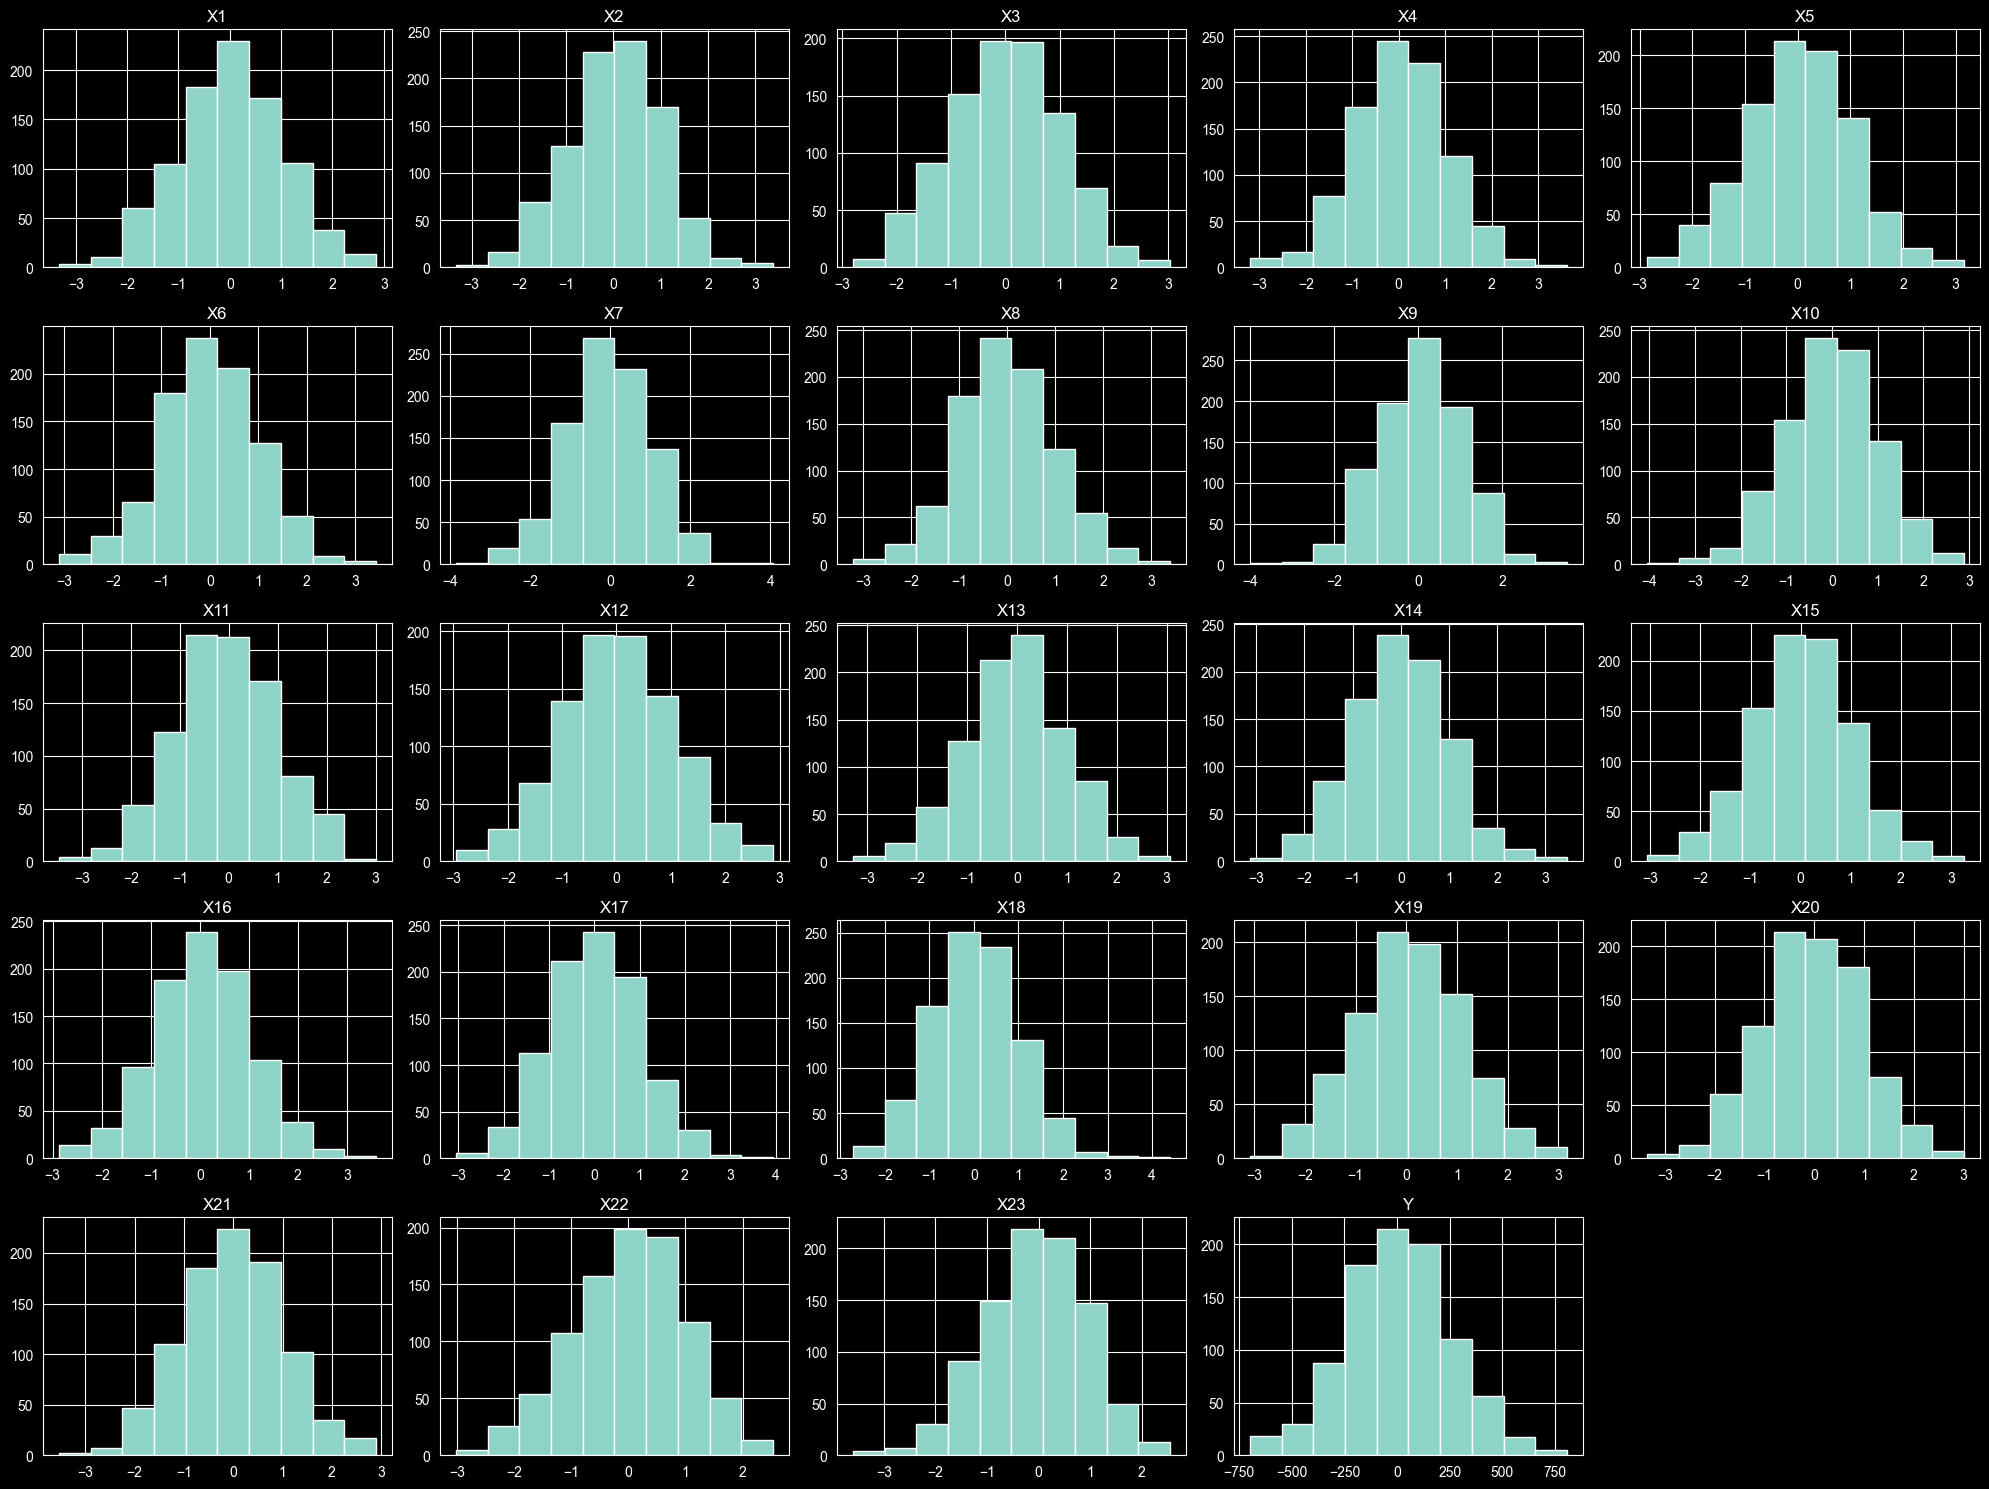

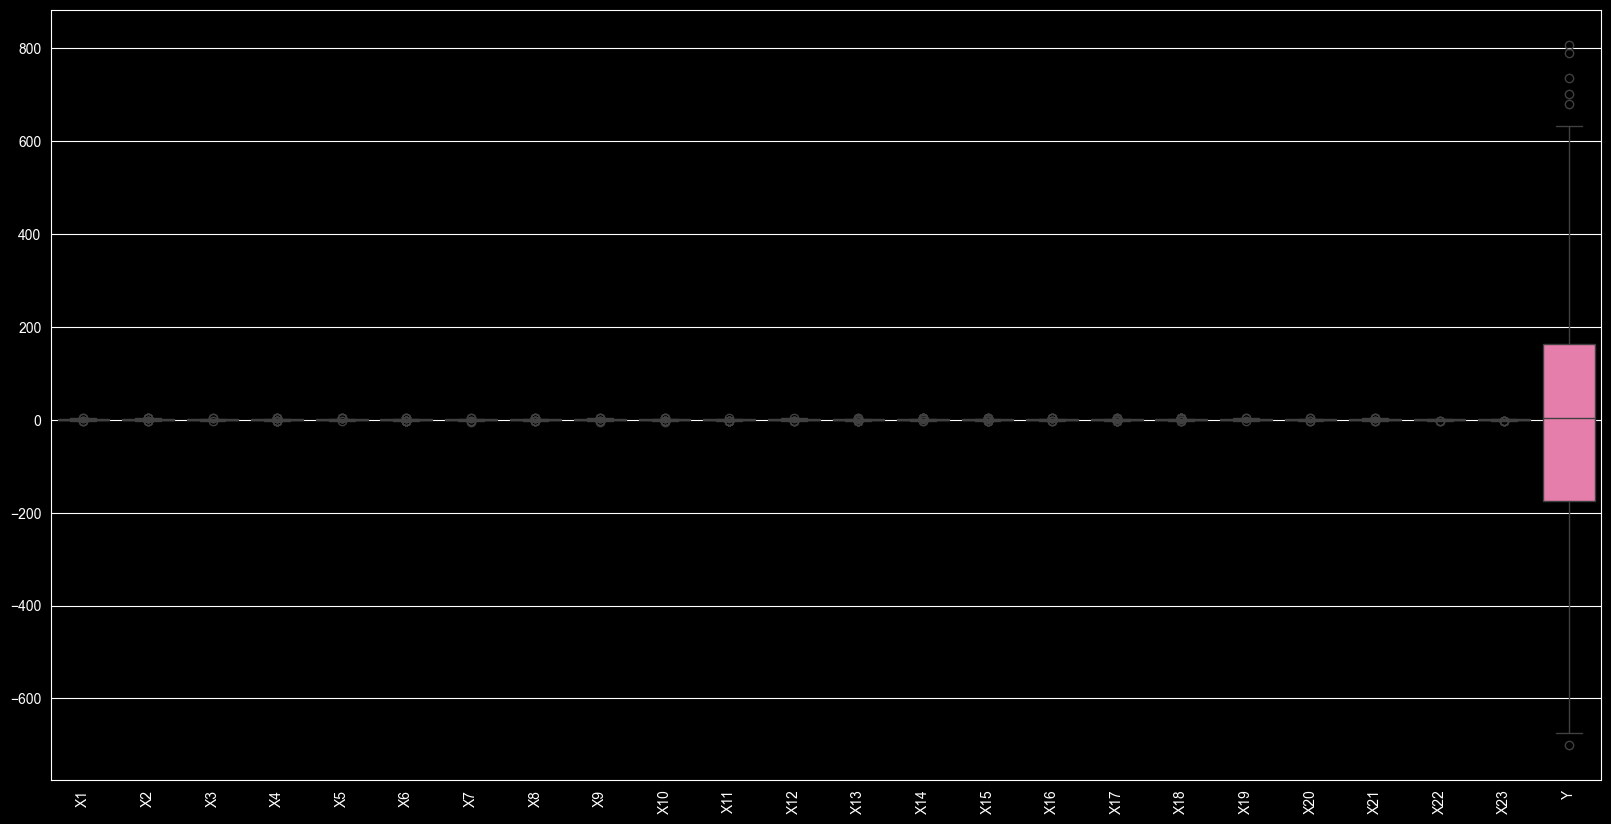

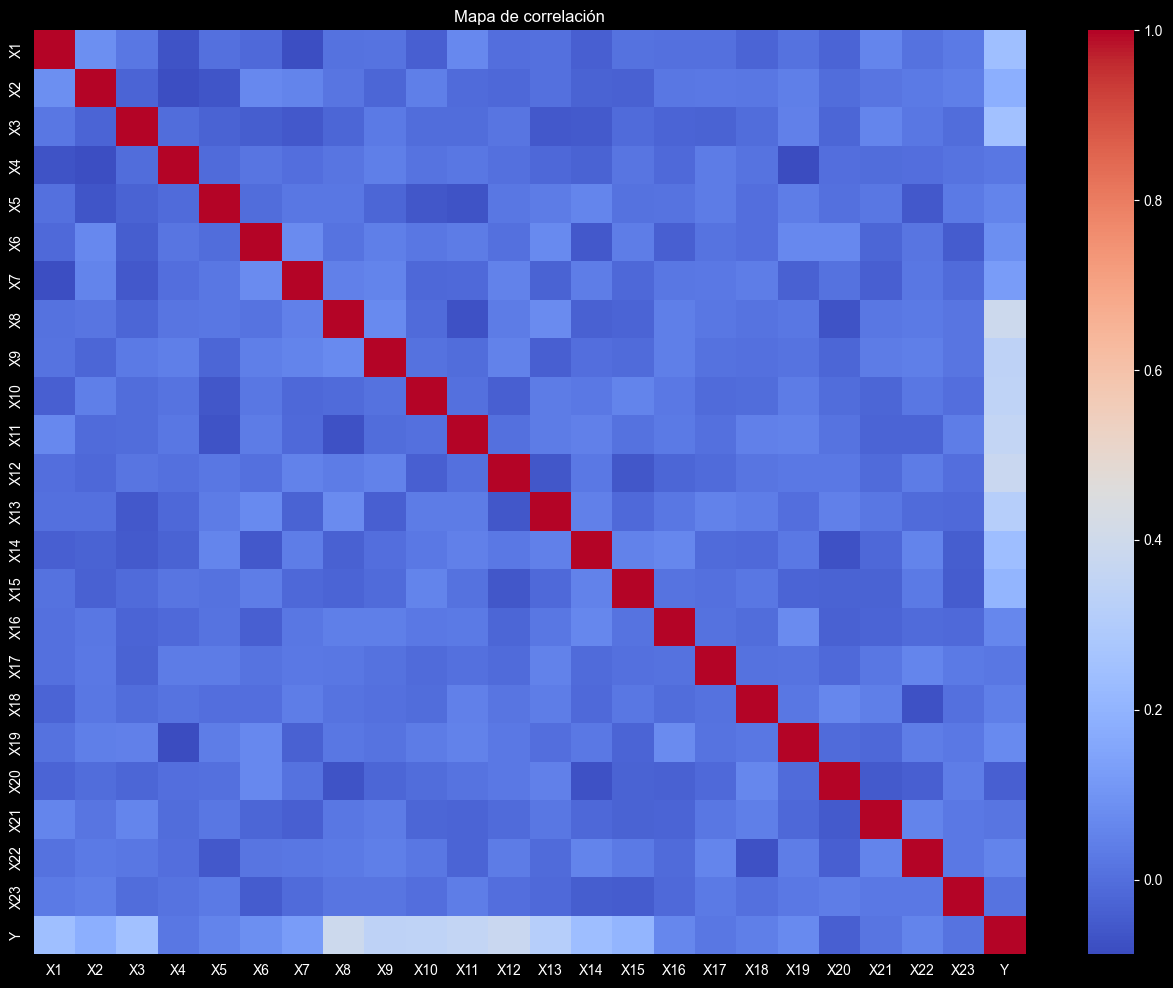

In [4]:

# ==========================================
# ANÁLISIS GRÁFICO
# ==========================================

# Histogramas

df.hist(figsize=(20,15))
plt.tight_layout()
plt.show()

# Boxplots

plt.figure(figsize=(20,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# Correlación

plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Mapa de correlación")
plt.show()



## Interpretación de los gráficos

Los histogramas permiten analizar la distribución de cada variable y observar si presentan simetría o dispersión significativa.

Los diagramas de caja permiten identificar posibles valores atípicos y diferencias de escala entre variables.

El mapa de correlación permite analizar relaciones lineales entre las variables predictoras y la variable respuesta.


In [5]:

# ==========================================
# DIVISIÓN ENTRENAMIENTO Y VALIDACIÓN
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.30,
    random_state = 20232285
)

# Escalamiento

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de validación:", X_test.shape)


Datos de entrenamiento: (644, 23)
Datos de validación: (276, 23)



## Interpretación

El 70% de las observaciones fueron utilizadas para entrenamiento y el 30% restante para validación.

Esto permite entrenar los modelos y posteriormente evaluar su capacidad predictiva utilizando datos que no fueron vistos durante el entrenamiento.

Además, se aplicó estandarización para evitar problemas derivados de diferencias de escala entre variables.


In [7]:

# ==========================================
# REGRESIÓN RIDGE
# ==========================================

alphas = [1, 50, 100]

resultados_ridge = {}

for a in alphas:

    ridge = Ridge(alpha=a)

    ridge.fit(X_train_scaled, y_train)

    pred = ridge.predict(X_test_scaled)

    mse = mean_squared_error(y_test, pred)

    resultados_ridge[a] = mse

    print(f"Ridge alpha = {a}")
    print("MSE:", mse)
    print()


Ridge alpha = 1
MSE: 500.69537432793067

Ridge alpha = 50
MSE: 737.9329820901537

Ridge alpha = 100
MSE: 1375.663936488243




## Interpretación Ridge

La regresión Ridge agrega una penalización cuadrática a los coeficientes del modelo para reducir el sobreajuste.

La función objetivo de Ridge es:

\[
\min \left( \sum_{i=1}^{n}(y_i-\hat{y}_i)^2 + \alpha \sum_{j=1}^{p}\beta_j^2 \right)
\]

Cuando el valor de alpha aumenta:

- los coeficientes se reducen
- el modelo se vuelve menos complejo
- puede aparecer subajuste si la penalización es excesiva

El mejor modelo será aquel que presente el menor error cuadrático medio.


In [8]:

# ==========================================
# VALIDACIÓN CRUZADA RIDGE
# ==========================================

alphas_cv = np.logspace(-3,3,100)

ridge_cv = RidgeCV(
    alphas=alphas_cv,
    scoring='neg_mean_squared_error',
    cv=5
)

ridge_cv.fit(X_train_scaled, y_train)

pred_ridge_cv = ridge_cv.predict(X_test_scaled)

mse_ridge_cv = mean_squared_error(y_test, pred_ridge_cv)

print("Mejor alpha:", ridge_cv.alpha_)
print("MSE Ridge CV:", mse_ridge_cv)


Mejor alpha: 0.01873817422860384
MSE Ridge CV: 501.28754468700305


In [9]:

# ==========================================
# REGRESIÓN RED ELÁSTICA
# ==========================================

elastic_cv = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9,1],
    alphas=np.logspace(-3,3,100),
    cv=5,
    random_state=20232285
)

elastic_cv.fit(X_train_scaled, y_train)

pred_elastic = elastic_cv.predict(X_test_scaled)

mse_elastic = mean_squared_error(y_test, pred_elastic)

print("Mejor valor de r:", elastic_cv.l1_ratio_)
print("Mejor alpha:", elastic_cv.alpha_)
print("MSE Elastic Net:", mse_elastic)


Mejor valor de r: 1.0
Mejor alpha: 0.23101297000831605
MSE Elastic Net: 494.60117402032876



## Interpretación Red Elástica

La Red Elástica combina las penalizaciones Ridge y Lasso.

\[
\min \left( \sum_{i=1}^{n}(y_i-\hat{y}_i)^2 + \alpha \left( r\sum |\beta_j| + (1-r)\sum \beta_j^2 \right) \right)
\]

- Si \(r\) se aproxima a 1, el modelo se comporta como Lasso.
- Si \(r\) se aproxima a 0, el modelo se comporta como Ridge.

La validación cruzada permite encontrar automáticamente los mejores valores de alpha y r.


In [10]:

# ==========================================
# COMPARACIÓN FINAL
# ==========================================

print("MSE Ridge CV:", mse_ridge_cv)
print("MSE Elastic Net:", mse_elastic)

if mse_ridge_cv < mse_elastic:

    mejor_modelo = ridge_cv
    print("\nEl mejor modelo es Ridge")

else:

    mejor_modelo = elastic_cv
    print("\nEl mejor modelo es Elastic Net")


MSE Ridge CV: 501.28754468700305
MSE Elastic Net: 494.60117402032876

El mejor modelo es Elastic Net


In [11]:

# ==========================================
# PREDICCIÓN CON LA MEDIANA
# ==========================================

medianas = np.median(X, axis=0)

medianas = medianas.reshape(1,-1)

medianas_scaled = scaler.transform(medianas)

prediccion = mejor_modelo.predict(medianas_scaled)

print("Predicción utilizando la mediana:")
print(prediccion)


Predicción utilizando la mediana:
[1.87080701]



# Conclusión

El modelo que presenta el menor error cuadrático medio es el más adecuado para realizar predicciones, debido a que logra una menor diferencia entre los valores reales y los valores estimados.

La validación cruzada permitió seleccionar automáticamente los mejores hiperparámetros para los modelos de Ridge y Red Elástica.

Finalmente, se realizó una predicción utilizando la mediana de todas las variables predictoras, representando una observación típica del conjunto de datos.
